# INTELIGENCIA ARTIFICIAL APLICADA
Dr. Edwin Villanueva Talavera (ervillanueva@pucp.edu.pe)

# Clasificación de prendas con CNN: Fashion MNIST

En este cuaderno se trabaja un problema de **clasificación multiclase de imágenes** usando el dataset **Fashion MNIST**.

Se usa una estrategia de validacion train/val/test para evaluar redes neuronales:

- **train**: datos usados para ajustar los pesos del modelo;
- **validation**: datos usados para comparar arquitecturas e hiperparámetros;
- **test**: datos reservados para la evaluación final.

La idea importante es que el conjunto de **test no se usa para elegir el modelo**.  
Solo se usa al final, cuando la arquitectura y los hiperparámetros ya fueron seleccionados.

## 1. Importación de librerías

Se importan las librerías necesarias para preparar los datos, entrenar modelos CNN y evaluar los resultados.

A diferencia de la versión con cross-validation, aquí **no se usa `KFold` ni `cross_val_score`**.

In [1]:
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import model_from_json

## 2. Configuración inicial

Se fija una semilla para hacer más reproducibles los resultados.  
En redes neuronales pueden existir pequeñas variaciones entre ejecuciones, pero fijar semillas ayuda a reducirlas.

In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Funciones auxiliares para evaluación

La primera función imprime un `classification_report`.  
Este reporte permite ver no solo el `accuracy`, sino también el **precision**, **recall** y **F1-score** por clase.

La segunda función genera gráficos de diagnóstico:

1. evolución de la pérdida (`loss`) en train y validation;
2. evolución del `accuracy` en train y validation;
3. matriz de confusión normalizada;
4. F1-score por clase en train, validation y test.

Estos gráficos ayudan a distinguir entre **subajuste**, **sobreajuste** y errores específicos entre clases.

In [3]:
def print_report(model, X, y, target_names, title="Modelo"):
    """Imprime el classification report de un modelo Keras."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)

    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(
        y,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    ))


def plot_model_results(model, model_name, history,
                       X_train, y_train,
                       X_val, y_val,
                       X_test, y_test,
                       target_names):
    """
    Genera un panel de gráficos para evaluar un modelo de clasificación multiclase.

    Nota didáctica:
    - Las curvas train/validation muestran cómo aprendió el modelo durante el entrenamiento.
    - La matriz de confusión muestra qué clases se confunden más entre sí.
    - El F1 por clase permite revisar si el modelo funciona bien para todas las clases,
      no solo en promedio.
    """
    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    train_f1 = f1_score(y_train, y_train_pred, average=None, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average=None, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average=None, zero_division=0)

    cm = confusion_matrix(y_test, y_test_pred, normalize="true")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(model_name, fontsize=15, fontweight="bold")

    # Loss
    axes[0, 0].plot(history.history["loss"], label="train")
    axes[0, 0].plot(history.history["val_loss"], label="validation")
    axes[0, 0].set_title("Evolución de la pérdida")
    axes[0, 0].set_xlabel("Época")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Accuracy
    axes[0, 1].plot(history.history["accuracy"], label="train")
    axes[0, 1].plot(history.history["val_accuracy"], label="validation")
    axes[0, 1].set_title("Evolución del accuracy")
    axes[0, 1].set_xlabel("Época")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Matriz de confusión
    im = axes[1, 0].imshow(cm)
    axes[1, 0].set_title("Matriz de confusión normalizada en test")
    axes[1, 0].set_xlabel("Clase predicha")
    axes[1, 0].set_ylabel("Clase real")
    axes[1, 0].set_xticks(np.arange(len(target_names)))
    axes[1, 0].set_yticks(np.arange(len(target_names)))
    axes[1, 0].set_xticklabels(target_names, rotation=45, ha="right")
    axes[1, 0].set_yticklabels(target_names)
    fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    # F1 por clase
    x = np.arange(len(target_names))
    width = 0.25

    axes[1, 1].bar(x - width, train_f1, width, label="train")
    axes[1, 1].bar(x, val_f1, width, label="validation")
    axes[1, 1].bar(x + width, test_f1, width, label="test")
    axes[1, 1].set_title("F1-score por clase")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(target_names, rotation=45, ha="right")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()
    axes[1, 1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Carga del dataset Fashion MNIST

Fashion MNIST contiene imágenes de prendas de vestir de **28 x 28 píxeles**.  
Cada imagen pertenece a una de 10 clases.

Keras entrega el dataset separado originalmente en 60 000 imágenes de entrenamiento y 10 000 imágenes de prueba.  
En este cuaderno tomaremos las 60 000 primeras como un conjunto inicial y luego lo dividiremos en **train** y **validation**.

In [4]:
mnist = keras.datasets.fashion_mnist

(X_full_raw, y_full), (X_test_raw, y_test) = mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

NUM_CLASSES = len(class_names)

print("Conjunto inicial para train/validation:", X_full_raw.shape, y_full.shape)
print("Conjunto test:", X_test_raw.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Conjunto inicial para train/validation: (60000, 28, 28) (60000,)
Conjunto test: (10000, 28, 28) (10000,)


### Visualización inicial de algunas imágenes

Antes de entrenar cualquier modelo, conviene mirar los datos.  
Esto ayuda a recordar que la red no recibe etiquetas abstractas, sino imágenes compuestas por intensidades de píxeles.

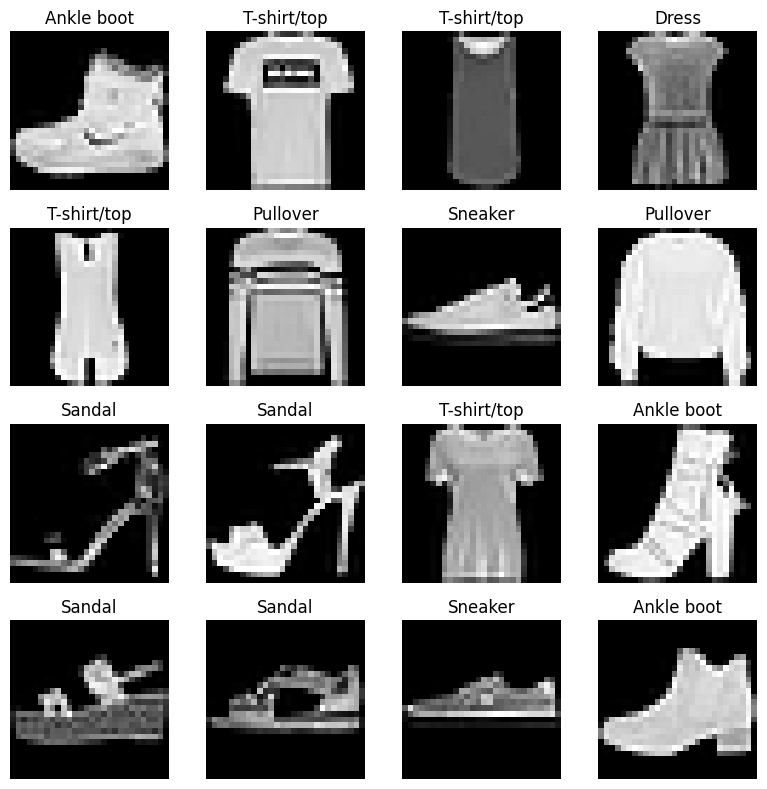

In [5]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_full_raw[i], cmap="gray")
    plt.title(class_names[y_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

También es útil revisar la distribución de clases.  
Fashion MNIST está bastante balanceado, pero esta verificación es una buena práctica antes de entrenar modelos de clasificación.

,clase_id,clase,n_muestras
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


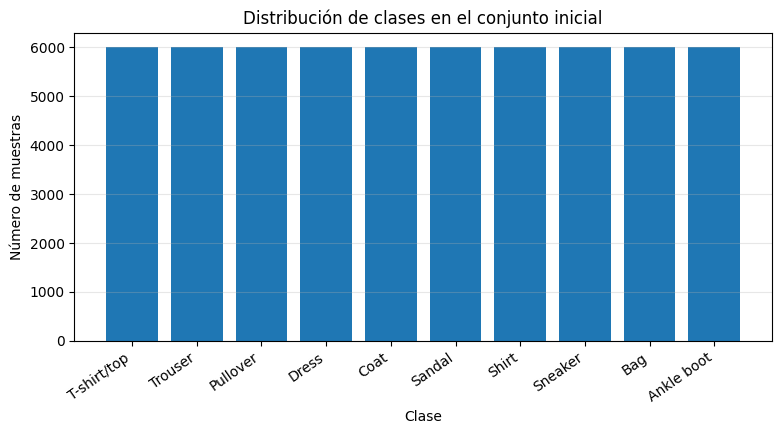

In [6]:
class_dist = pd.Series(y_full).value_counts().sort_index()
class_dist_df = pd.DataFrame({
    "clase_id": class_dist.index,
    "clase": [class_names[i] for i in class_dist.index],
    "n_muestras": class_dist.values
})

display(class_dist_df)

plt.figure(figsize=(9, 4))
plt.bar(class_dist_df["clase"], class_dist_df["n_muestras"])
plt.title("Distribución de clases en el conjunto inicial")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Partición train / validation / test

Se divide el conjunto inicial en:

- **train**: 80% del conjunto inicial;
- **validation**: 20% del conjunto inicial;
- **test**: se conserva el conjunto de prueba original de Fashion MNIST.

Se usa `stratify=y_full` para preservar aproximadamente la proporción de clases en train y validation.

In [7]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full_raw,
    y_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_full
)

print("Train:      ", X_train_raw.shape, y_train.shape)
print("Validation: ", X_val_raw.shape, y_val.shape)
print("Test:       ", X_test_raw.shape, y_test.shape)

Train:       (48000, 28, 28) (48000,)
Validation:  (12000, 28, 28) (12000,)
Test:        (10000, 28, 28) (10000,)


## 6. Escalamiento y preparación de imágenes

Los valores de los píxeles van de 0 a 255.  
Para facilitar el entrenamiento, se escalan al rango **[0, 1]** dividiendo entre 255.

Además, las capas convolucionales esperan datos con forma:

`(n_muestras, alto, ancho, canales)`

Como Fashion MNIST está en escala de grises, tiene **1 canal**.

In [8]:
X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# Agrega la dimensión del canal: de (n, 28, 28) a (n, 28, 28, 1).
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

INPUT_SHAPE = X_train.shape[1:]

print("Shape usado por la CNN:", INPUT_SHAPE)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Shape usado por la CNN: (28, 28, 1)
Train: (48000, 28, 28, 1)
Validation: (12000, 28, 28, 1)
Test: (10000, 28, 28, 1)


### Nota sobre el target

En esta versión se usan las etiquetas como enteros (`0`, `1`, ..., `9`) y la función de pérdida `sparse_categorical_crossentropy`.

Por eso **no es necesario convertir `y_train`, `y_val` ni `y_test` a one-hot encoding**.  
Keras se encarga internamente de interpretar cada entero como una clase.

## 7. Modelo base 1: MLP de referencia

Aunque el foco del cuaderno es CNN, se mantiene un modelo MLP como referencia.  
La MLP aplana la imagen de 28 x 28 píxeles y la trata como un vector de 784 atributos.

Esto permite comparar la diferencia entre:

- una red que ignora la estructura espacial de la imagen, como la MLP;
- una red que aprovecha vecindades locales mediante filtros convolucionales, como la CNN.

In [9]:
def build_model1_mlp(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(300, activation="relu"),
        layers.Dense(100, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="model1_mlp_reference")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model1 = build_model1_mlp(INPUT_SHAPE, NUM_CLASSES)
model1.summary()

Model: "model1_mlp_reference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_model1 = model1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8171 - loss: 0.5149 - val_accuracy: 0.8597 - val_loss: 0.3866
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8625 - loss: 0.3749 - val_accuracy: 0.8712 - val_loss: 0.3515
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8777 - loss: 0.3319 - val_accuracy: 0.8740 - val_loss: 0.3415
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8863 - loss: 0.3055 - val_accuracy: 0.8817 - val_loss: 0.3301
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8936 - loss: 0.2854 - val_accuracy: 0.8839 - val_loss: 0.3236
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9004 - loss: 0.2671 - val_accuracy: 0.8859 - val_loss: 0.3202
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9040 - loss: 0.2537 - val_accuracy: 0.8844 - val_loss: 0.3256
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9102 - loss: 0.2395 - val_accuracy: 0.

### Evaluación del modelo base 1 en validation

El conjunto de validation se usa para comparar modelos durante el desarrollo.  
El conjunto de test todavía no debe usarse, porque aún estamos tomando decisiones de modelamiento.

In [11]:
print_report(
    model=model1,
    X=X_val,
    y=y_val,
    target_names=class_names,
    title="Modelo base 1: MLP de referencia - validation"
)

Modelo base 1: MLP de referencia - validation
              precision    recall  f1-score   support

 T-shirt/top     0.8423    0.8633    0.8527      1200
     Trouser     0.9890    0.9750    0.9820      1200
    Pullover     0.7778    0.8633    0.8183      1200
       Dress     0.9176    0.8817    0.8993      1200
        Coat     0.8329    0.7392    0.7832      1200
      Sandal     0.9737    0.9558    0.9647      1200
       Shirt     0.7105    0.7342    0.7221      1200
     Sneaker     0.9147    0.9742    0.9435      1200
         Bag     0.9773    0.9708    0.9741      1200
  Ankle boot     0.9765    0.9350    0.9553      1200

    accuracy                         0.8892     12000
   macro avg     0.8912    0.8892    0.8895     12000
weighted avg     0.8912    0.8892    0.8895     12000



## 8. Modelo base 2: CNN simple

La CNN usa filtros convolucionales para detectar patrones locales en la imagen, por ejemplo bordes, esquinas o pequeñas texturas.

La arquitectura base contiene:

- una capa convolucional con 32 filtros de 5 x 5;
- una capa `MaxPooling2D`;
- una capa densa de 100 neuronas;
- una capa de salida con 10 neuronas y activación `softmax`.

In [12]:
def build_model2_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(filters=32, kernel_size=5, strides=1, padding="valid", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(100, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="model2_cnn_simple")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model2 = build_model2_cnn(INPUT_SHAPE, NUM_CLASSES)
model2.summary()

Model: "model2_cnn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │       460,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,742 (1.77 MB)

 Trainable params: 462,742 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_model2 = model2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8342 - loss: 0.4663 - val_accuracy: 0.8836 - val_loss: 0.3338
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8892 - loss: 0.3133 - val_accuracy: 0.8938 - val_loss: 0.2975
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9042 - loss: 0.2690 - val_accuracy: 0.9000 - val_loss: 0.2787
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9137 - loss: 0.2379 - val_accuracy: 0.9017 - val_loss: 0.2719
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9234 - loss: 0.2116 - val_accuracy: 0.9053 - val_loss: 0.2679
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9313 - loss: 0.1889 - val_accuracy: 0.9058 - val_loss: 0.2699
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9390 - loss: 0.1688 - val_accuracy: 0.9081 - val_loss: 0.2672
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9459 - loss: 0.1502 - val_accuracy: 0.

### Evaluación del modelo base 2 en validation

Aquí se revisa si la CNN simple mejora a la MLP de referencia.  
La comparación se hace con validation, no con test.

In [14]:
print_report(
    model=model2,
    X=X_val,
    y=y_val,
    target_names=class_names,
    title="Modelo base 2: CNN simple - validation"
)

Modelo base 2: CNN simple - validation
              precision    recall  f1-score   support

 T-shirt/top     0.9005    0.8375    0.8679      1200
     Trouser     0.9907    0.9783    0.9845      1200
    Pullover     0.8547    0.8725    0.8635      1200
       Dress     0.9296    0.8908    0.9098      1200
        Coat     0.8662    0.7983    0.8309      1200
      Sandal     0.9782    0.9725    0.9753      1200
       Shirt     0.6963    0.8233    0.7545      1200
     Sneaker     0.9409    0.9817    0.9608      1200
         Bag     0.9849    0.9817    0.9833      1200
  Ankle boot     0.9853    0.9508    0.9678      1200

    accuracy                         0.9087     12000
   macro avg     0.9127    0.9088    0.9098     12000
weighted avg     0.9127    0.9087    0.9098     12000



### Comparación de los modelos base

Se comparan ambos modelos usando métricas calculadas en validation.  
Esta comparación sirve para justificar por qué conviene continuar el tuning sobre una CNN.

In [15]:
base_results = []

for model_name, model in [
    ("MLP referencia", model1),
    ("CNN simple", model2)
]:
    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    val_f1_macro = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

    base_results.append({
        "modelo": model_name,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_f1_macro": val_f1_macro
    })

base_results_df = pd.DataFrame(base_results).sort_values(
    by="val_f1_macro",
    ascending=False
)

display(base_results_df)

,modelo,val_loss,val_accuracy,val_f1_macro
1,CNN simple,0.292675,0.90875,0.909828
0,MLP referencia,0.331321,0.88925,0.889515


## 9. Búsqueda en grilla de hiperparámetros para CNN

Ahora se realiza una búsqueda sistemática de configuraciones CNN.

| Hiperparámetro | Valores |
|---|---|
| `num_conv_blocks` | 1, 2 |
| `filters` | 16, 32 |
| `kernel_size` | 3, 5 |
| `dense_units` | 64, 128 |
| `learning_rate` | `1e-4`, `1e-3` |
| `optimizer` | Adam |
| épocas por configuración | 5 |

Cada bloque convolucional contiene:

1. una capa `Conv2D`;
2. una capa `MaxPooling2D`.

La métrica principal para seleccionar la mejor configuración será el **macro-F1 en validation**.  
Aunque Fashion MNIST está balanceado, el macro-F1 permite observar si el modelo mantiene un desempeño razonable en todas las clases.

In [16]:
def build_grid_cnn(input_shape, num_classes,
                   num_conv_blocks,
                   filters,
                   kernel_size,
                   dense_units,
                   learning_rate):
    """
    Construye una CNN configurable para usarla en la búsqueda en grilla.

    Parámetros principales:
    - num_conv_blocks: cantidad de bloques Conv2D + MaxPooling2D.
    - filters: número de filtros en el primer bloque convolucional.
    - kernel_size: tamaño de la ventana del filtro convolucional.
    - dense_units: número de neuronas en la capa densa previa a la salida.
    - learning_rate: tasa de aprendizaje del optimizador Adam.
    """
    model = keras.Sequential(name="grid_cnn")
    model.add(layers.Input(shape=input_shape))

    for block_id in range(num_conv_blocks):
        # En el segundo bloque se duplica el número de filtros.
        # Esto permite que capas más profundas aprendan más patrones.
        current_filters = filters * (2 ** block_id)

        model.add(layers.Conv2D(
            filters=current_filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu"
        ))
        model.add(layers.MaxPooling2D(pool_size=2))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
param_grid = {
    "num_conv_blocks": [1, 2],
    "filters": [16, 32],
    "kernel_size": [3, 5],
    "dense_units": [64, 128],
    "learning_rate": [1e-4, 1e-3],
}

grid_combinations = list(itertools.product(
    param_grid["num_conv_blocks"],
    param_grid["filters"],
    param_grid["kernel_size"],
    param_grid["dense_units"],
    param_grid["learning_rate"],
))

print("Número total de combinaciones:", len(grid_combinations))

Número total de combinaciones: 32


La siguiente celda entrena cada configuración durante pocas épocas.  
Luego calcula el **macro-F1 en validation**, que será el criterio para seleccionar el mejor modelo.

Nota didáctica: durante una búsqueda de hiperparámetros, el conjunto de test debe permanecer intacto.  
Si se usa test para elegir hiperparámetros, la evaluación final deja de ser honesta.

In [19]:
EPOCHS_GRID = 5
BATCH_SIZE_GRID = 64

search_results = []
t0_total = time.time()

for trial_id, (num_conv_blocks, filters, kernel_size, dense_units, learning_rate) in enumerate(grid_combinations, start=1):

    print(
        f"Trial {trial_id:02d}/{len(grid_combinations)} | "
        f"blocks={num_conv_blocks}, filters={filters}, "
        f"kernel={kernel_size}, dense={dense_units}, lr={learning_rate}"
    )

    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_grid_cnn(
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        num_conv_blocks=num_conv_blocks,
        filters=filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate
    )

    t0 = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_GRID,
        batch_size=BATCH_SIZE_GRID,
        verbose=0
    )

    elapsed = time.time() - t0

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

    val_f1_macro = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    val_f1_weighted = f1_score(
        y_val,
        y_val_pred,
        average="weighted",
        zero_division=0
    )

    search_results.append({
        "trial_id": trial_id,
        "num_conv_blocks": num_conv_blocks,
        "filters": filters,
        "kernel_size": kernel_size,
        "dense_units": dense_units,
        "learning_rate": learning_rate,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_f1_macro": val_f1_macro,
        "val_f1_weighted": val_f1_weighted,
        "time_sec": elapsed
    })

total_time = time.time() - t0_total

print("-" * 80)
print(f"Búsqueda en grilla finalizada en {total_time/60:.2f} minutos")

Trial 01/32 | blocks=1, filters=16, kernel=3, dense=64, lr=0.0001
Trial 02/32 | blocks=1, filters=16, kernel=3, dense=64, lr=0.001
Trial 03/32 | blocks=1, filters=16, kernel=3, dense=128, lr=0.0001
Trial 04/32 | blocks=1, filters=16, kernel=3, dense=128, lr=0.001
Trial 05/32 | blocks=1, filters=16, kernel=5, dense=64, lr=0.0001
Trial 06/32 | blocks=1, filters=16, kernel=5, dense=64, lr=0.001
Trial 07/32 | blocks=1, filters=16, kernel=5, dense=128, lr=0.0001
Trial 08/32 | blocks=1, filters=16, kernel=5, dense=128, lr=0.001
Trial 09/32 | blocks=1, filters=32, kernel=3, dense=64, lr=0.0001
Trial 10/32 | blocks=1, filters=32, kernel=3, dense=64, lr=0.001
Trial 11/32 | blocks=1, filters=32, kernel=3, dense=128, lr=0.0001
Trial 12/32 | blocks=1, filters=32, kernel=3, dense=128, lr=0.001
Trial 13/32 | blocks=1, filters=32, kernel=5, dense=64, lr=0.0001
Trial 14/32 | blocks=1, filters=32, kernel=5, dense=64, lr=0.001
Trial 15/32 | blocks=1, filters=32, kernel=5, dense=128, lr=0.0001
Trial 16/3

Se ordenan los resultados de mayor a menor macro-F1 en validation.

In [20]:
results_df = pd.DataFrame(search_results)
results_df = results_df.sort_values(
    by="val_f1_macro",
    ascending=False
).reset_index(drop=True)

display(results_df.head(10))

,trial_id,num_conv_blocks,filters,kernel_size,dense_units,learning_rate,val_loss,val_accuracy,val_f1_macro,val_f1_weighted,time_sec
0,32,2,32,5,128,0.001,0.237763,0.917167,0.917140,0.917140,22.576843
1,28,2,32,3,128,0.001,0.250911,0.913167,0.914111,0.914111,21.085661
2,26,2,32,3,64,0.001,0.243232,0.911667,0.912216,0.912216,18.547894
3,16,1,32,5,128,0.001,0.264149,0.910333,0.911665,0.911665,17.282771
4,20,2,16,3,128,0.001,0.248981,0.910833,0.911498,0.911498,17.961163
5,12,1,32,3,128,0.001,0.260048,0.909667,0.910475,0.910475,17.517346
6,6,1,16,5,64,0.001,0.260219,0.908833,0.909208,0.909208,15.560126
7,18,2,16,3,64,0.001,0.253841,0.908917,0.908893,0.908893,18.518266
8,8,1,16,5,128,0.001,0.259102,0.907917,0.908474,0.908474,15.719296
9,24,2,16,5,128,0.001,0.255339,0.907417,0.908211,0.908211,21.189251


Se visualiza el desempeño de las configuraciones probadas.  
Cada punto representa una combinación de hiperparámetros ordenada según su desempeño en validation.

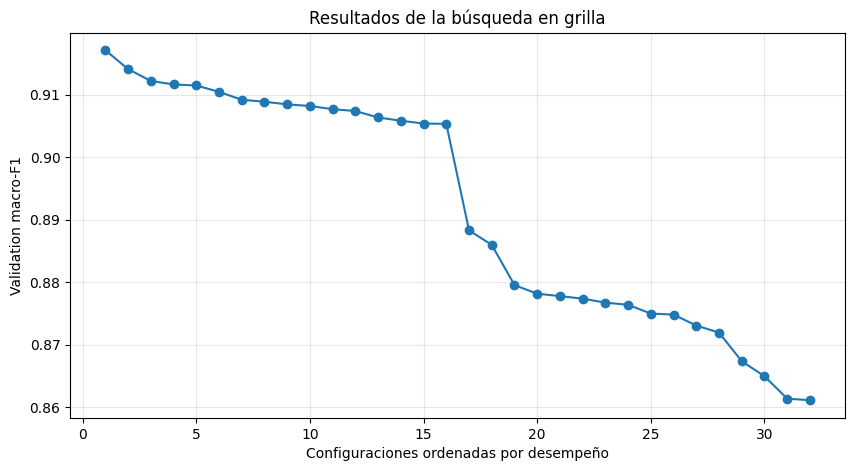

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(results_df) + 1), results_df["val_f1_macro"], marker="o")
plt.title("Resultados de la búsqueda en grilla")
plt.xlabel("Configuraciones ordenadas por desempeño")
plt.ylabel("Validation macro-F1")
plt.grid(alpha=0.3)
plt.show()

### Visualización de las top 5 configuraciones con coordenadas paralelas

Antes de elegir el modelo final, se visualizan las **cinco mejores configuraciones** según `val_f1_macro`.

Este gráfico permite comparar, en una sola figura, cómo cambian los hiperparámetros entre las configuraciones más competitivas.

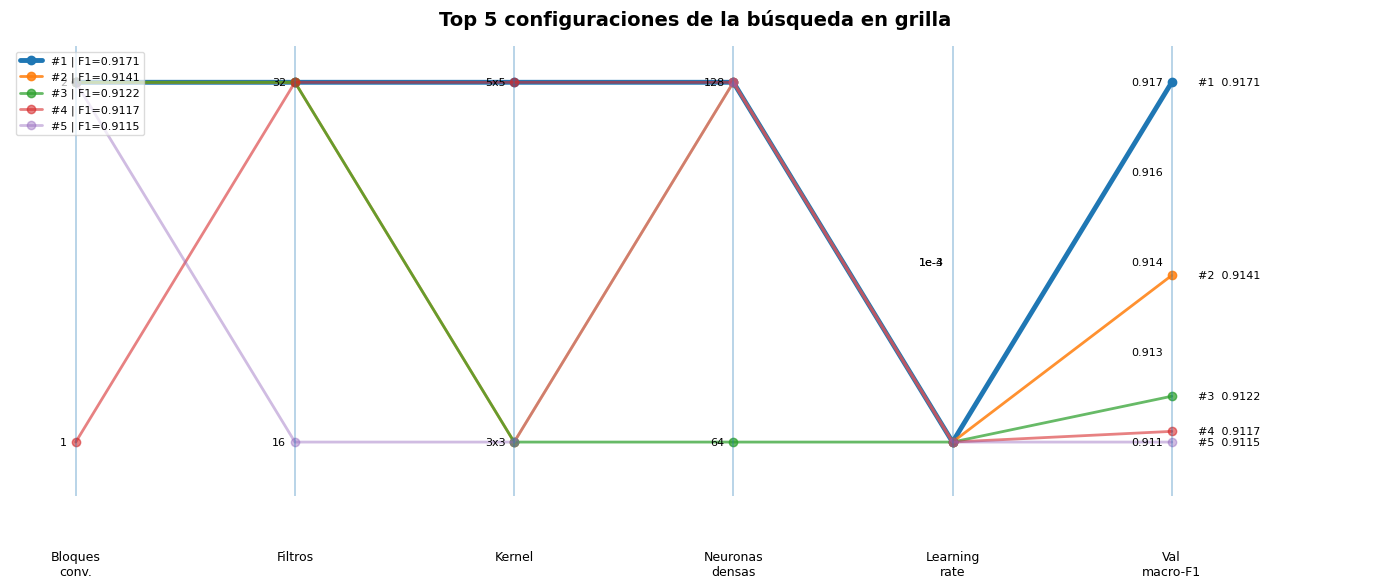

In [22]:
top_n = 5
top5_df = results_df.head(top_n).copy()
top5_df["rank"] = np.arange(1, len(top5_df) + 1)

AXES = [
    ("num_conv_blocks", "Bloques\nconv.", {1: "1", 2: "2"}),
    ("filters", "Filtros", {16: "16", 32: "32"}),
    ("kernel_size", "Kernel", {3: "3x3", 5: "5x5"}),
    ("dense_units", "Neuronas\ndensas", {64: "64", 128: "128"}),
    ("learning_rate", "Learning\nrate", {1e-4: "1e-4", 1e-3: "1e-3"}),
    ("val_f1_macro", "Val\nmacro-F1", None),
]

COLS = [axis[0] for axis in AXES]

# Normalización min-max por eje para poder graficar variables con escalas distintas.
df_plot = top5_df[COLS].copy()
mins, maxs = {}, {}

for col in COLS:
    mins[col] = df_plot[col].min()
    maxs[col] = df_plot[col].max()
    col_range = maxs[col] - mins[col]
    df_plot[col] = (df_plot[col] - mins[col]) / (col_range if col_range > 0 else 1)

x_positions = np.arange(len(AXES))

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(
    "Top 5 configuraciones de la búsqueda en grilla",
    fontsize=14,
    fontweight="bold",
    pad=15
)

for idx, row in top5_df.iterrows():
    rank = int(row["rank"])
    y_values = df_plot.loc[idx, COLS].values

    # La mejor configuración se resalta con una línea más gruesa.
    linewidth = 3.5 if rank == 1 else 2.0
    alpha = 1.0 - (rank - 1) * 0.14

    ax.plot(
        x_positions,
        y_values,
        marker="o",
        linewidth=linewidth,
        alpha=alpha,
        solid_capstyle="round",
        label=f"#{rank} | F1={row['val_f1_macro']:.4f}"
    )

    ax.annotate(
        f"#{rank}  {row['val_f1_macro']:.4f}",
        xy=(x_positions[-1], y_values[-1]),
        xytext=(x_positions[-1] + 0.12, y_values[-1]),
        fontsize=8,
        va="center"
    )

# Ejes verticales y etiquetas de valores posibles.
for axis_idx, (col, label, tickmap) in enumerate(AXES):
    ax.axvline(axis_idx, linewidth=1.1, alpha=0.4)
    ax.text(
        axis_idx,
        -0.12,
        label,
        ha="center",
        va="top",
        fontsize=9,
        transform=ax.get_xaxis_transform()
    )

    if tickmap is not None:
        for raw_value, text_label in tickmap.items():
            if maxs[col] == mins[col]:
                norm_value = 0.5
            else:
                norm_value = (raw_value - mins[col]) / (maxs[col] - mins[col])

            if 0 <= norm_value <= 1:
                ax.text(
                    axis_idx - 0.04,
                    norm_value,
                    text_label,
                    ha="right",
                    va="center",
                    fontsize=8
                )
    else:
        for norm_value in np.linspace(0, 1, 5):
            raw_value = mins[col] + norm_value * (maxs[col] - mins[col])
            ax.text(
                axis_idx - 0.04,
                norm_value,
                f"{raw_value:.3f}",
                ha="right",
                va="center",
                fontsize=8
            )

ax.set_xlim(-0.3, len(AXES) - 0.05)
ax.set_ylim(-0.15, 1.10)
ax.axis("off")
ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

## 10. Selección del mejor modelo

Se selecciona la configuración con mayor `val_f1_macro`.

Esta selección se hace usando **solo validation**.  
El conjunto de test sigue reservado para la evaluación final.

In [23]:
best_config = results_df.iloc[0].to_dict()

print("Mejor configuración encontrada:")
for key in ["num_conv_blocks", "filters", "kernel_size", "dense_units", "learning_rate"]:
    print(f"{key}: {best_config[key]}")

print(f"Mejor macro-F1 en validation: {best_config['val_f1_macro']:.4f}")
print(f"Accuracy en validation de esa configuración: {best_config['val_accuracy']:.4f}")

Mejor configuración encontrada:
num_conv_blocks: 2.0
filters: 32.0
kernel_size: 5.0
dense_units: 128.0
learning_rate: 0.001
Mejor macro-F1 en validation: 0.9171
Accuracy en validation de esa configuración: 0.9172


## 11. Entrenamiento final del mejor modelo

Con la configuración seleccionada, se entrena un modelo final durante más épocas.

En este punto ya no estamos comparando configuraciones.  
Estamos entrenando la arquitectura elegida para luego evaluarla en test.

In [24]:
tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)

final_model = build_grid_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    num_conv_blocks=int(best_config["num_conv_blocks"]),
    filters=int(best_config["filters"]),
    kernel_size=int(best_config["kernel_size"]),
    dense_units=int(best_config["dense_units"]),
    learning_rate=float(best_config["learning_rate"])
)

final_model.summary()

Model: "grid_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,922 (1.74 MB)

 Trainable params: 454,922 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_final = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8352 - loss: 0.4560 - val_accuracy: 0.8836 - val_loss: 0.3243
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8942 - loss: 0.2924 - val_accuracy: 0.9025 - val_loss: 0.2686
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9107 - loss: 0.2439 - val_accuracy: 0.9078 - val_loss: 0.2612
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9236 - loss: 0.2095 - val_accuracy: 0.9118 - val_loss: 0.2504
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9331 - loss: 0.1818 - val_accuracy: 0.9115 - val_loss: 0.2450
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9424 - loss: 0.1559 - val_accuracy: 0.9127 - val_loss: 0.2530
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9517 - loss: 0.1324 - val_accuracy: 0.9133 - val_loss: 0.2732
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9583 - loss: 0.1148 - val_accuracy: 0.

## 12. Evaluación final en test

El conjunto de test se usa recién ahora, una vez elegida la configuración del modelo.  
Esto permite obtener una estimación más honesta del desempeño esperado en datos nuevos.

In [26]:
print_report(
    model=final_model,
    X=X_test,
    y=y_test,
    target_names=class_names,
    title="Modelo final seleccionado por validation macro-F1 - test"
)

Modelo final seleccionado por validation macro-F1 - test
              precision    recall  f1-score   support

 T-shirt/top     0.8845    0.8420    0.8627      1000
     Trouser     0.9880    0.9840    0.9860      1000
    Pullover     0.8477    0.8850    0.8659      1000
       Dress     0.9173    0.9090    0.9131      1000
        Coat     0.8583    0.8720    0.8651      1000
      Sandal     0.9878    0.9720    0.9798      1000
       Shirt     0.7386    0.7460    0.7423      1000
     Sneaker     0.9347    0.9880    0.9606      1000
         Bag     0.9848    0.9730    0.9789      1000
  Ankle boot     0.9875    0.9500    0.9684      1000

    accuracy                         0.9121     10000
   macro avg     0.9129    0.9121    0.9123     10000
weighted avg     0.9129    0.9121    0.9123     10000



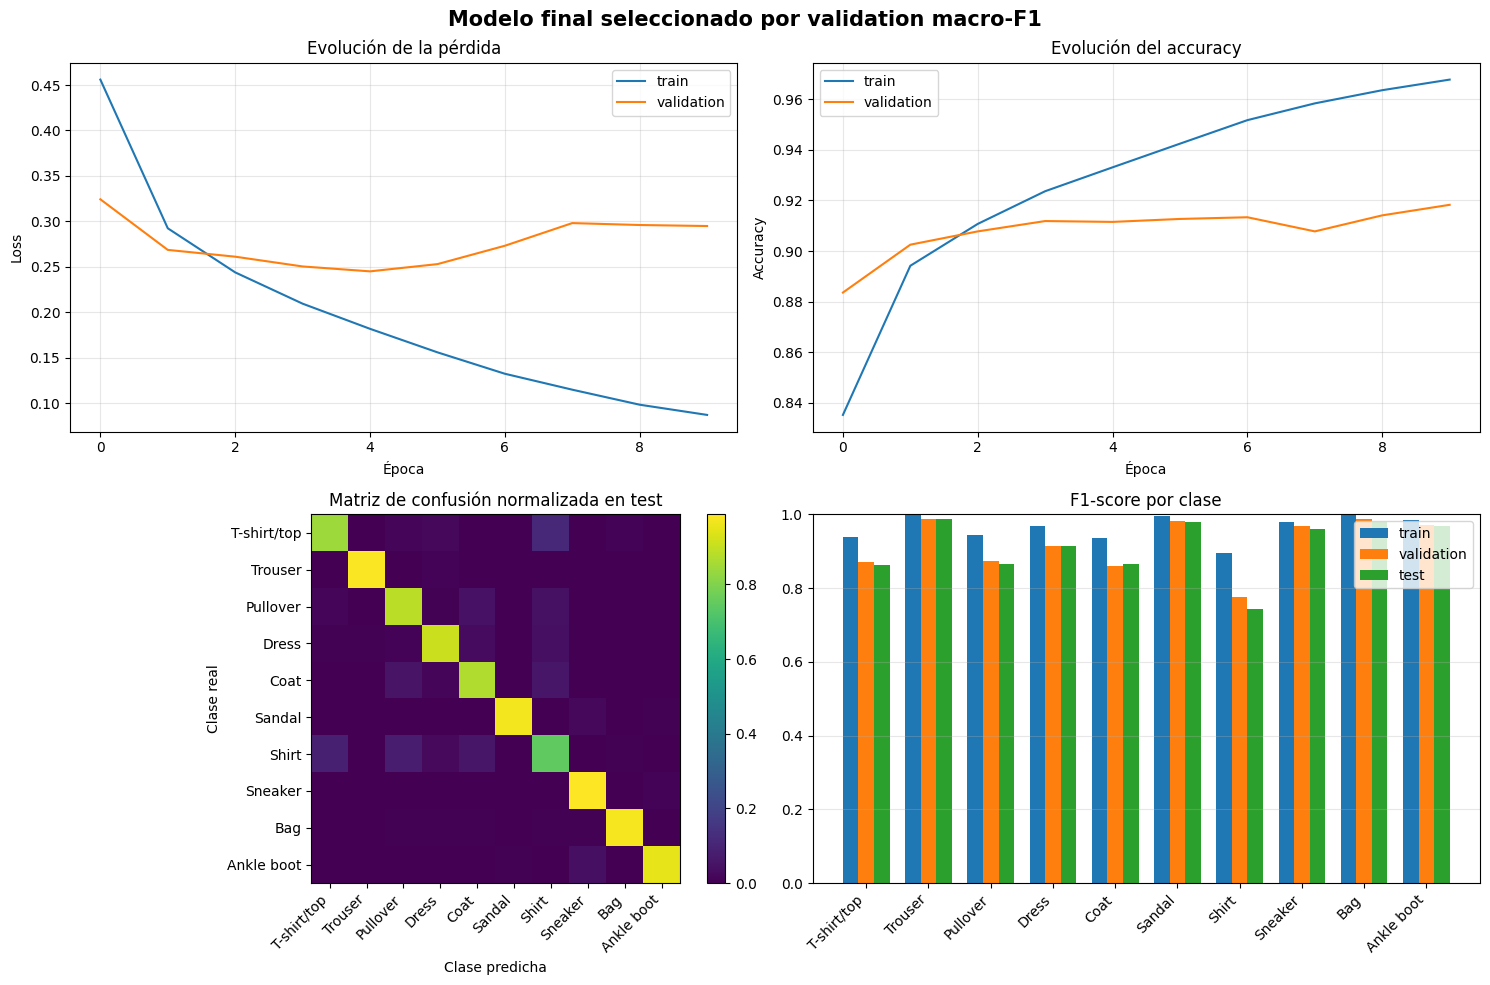

In [27]:
plot_model_results(
    model=final_model,
    model_name="Modelo final seleccionado por validation macro-F1",
    history=history_final,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    target_names=class_names
)

## 13. Análisis de errores con matriz de confusión

La matriz de confusión permite identificar qué clases se confunden con mayor frecuencia.

En Fashion MNIST, es común observar confusiones entre clases visualmente parecidas, por ejemplo:

- `T-shirt/top`, `Shirt`, `Pullover` y `Coat`;
- `Sneaker` y `Ankle boot`.

El análisis no debe quedarse solo en el `accuracy`; también conviene revisar los errores por clase.

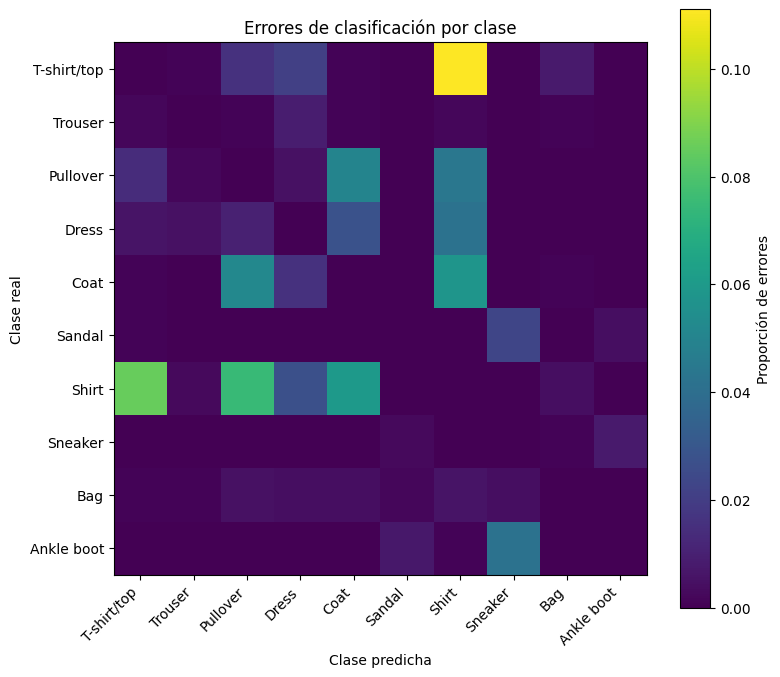

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,842,1,16,21,1,0,111,0,8,0
Trouser,2,984,1,9,1,0,2,0,1,0
Pullover,14,2,885,5,50,0,44,0,0,0
Dress,6,5,10,909,28,0,42,0,0,0
Coat,1,0,52,16,872,0,58,0,1,0
Sandal,1,0,0,0,0,972,0,23,0,4
Shirt,85,3,75,27,60,0,746,0,4,0
Sneaker,0,0,0,0,0,3,0,988,1,8
Bag,1,1,5,4,4,2,6,4,973,0
Ankle boot,0,0,0,0,0,7,1,42,0,950


In [28]:
y_test_pred = np.argmax(final_model.predict(X_test, verbose=0), axis=1)

conf_mx = confusion_matrix(y_test, y_test_pred)

# Normaliza por filas para interpretar porcentajes dentro de cada clase real.
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

# Se coloca 0 en la diagonal para resaltar únicamente los errores.
errors_only = norm_conf_mx.copy()
np.fill_diagonal(errors_only, 0)

plt.figure(figsize=(8, 7))
plt.imshow(errors_only)
plt.title("Errores de clasificación por clase")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(np.arange(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(np.arange(NUM_CLASSES), class_names)
plt.colorbar(label="Proporción de errores")
plt.tight_layout()
plt.show()

display(pd.DataFrame(conf_mx, index=class_names, columns=class_names))

## 14. Guardar el modelo final en disco

Una forma simple de guardar un modelo Keras es separar:

- la **topología** del modelo, guardada en formato JSON;
- los **pesos**, guardados en formato HDF5.

Luego, ambos archivos pueden cargarse para volver a usar el clasificador.

In [29]:
model_json = final_model.to_json()

with open("modelo_final_topologia.json", "w") as json_file:
    json_file.write(model_json)

final_model.save_weights("modelo_final_pesos.weights.h5")

print("Modelo guardado en disco")

Modelo guardado en disco


## 15. Cargar el modelo guardado

Se reconstruye el modelo desde el archivo JSON y luego se cargan los pesos entrenados.

In [30]:
json_file = open("modelo_final_topologia.json", "r")
loaded_model_json = json_file.read()
json_file.close()

model_cargado = model_from_json(loaded_model_json)
model_cargado.load_weights("modelo_final_pesos.weights.h5")

model_cargado.compile(
    optimizer=keras.optimizers.Adam(learning_rate=float(best_config["learning_rate"])),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo cargado de disco")

Modelo cargado de disco


## 16. Ejemplo de inferencia con una imagen de test

Finalmente, se toma una imagen del conjunto de test y se predice su clase.

Pasos importantes:

1. se toma la imagen original;
2. se escala al rango `[0, 1]`;
3. se agrega la dimensión del canal;
4. se obtiene la distribución de probabilidades producida por la red.

Clase real: Pullover
Clase predicha: Pullover
Probabilidad asignada a la clase predicha: 1.0000


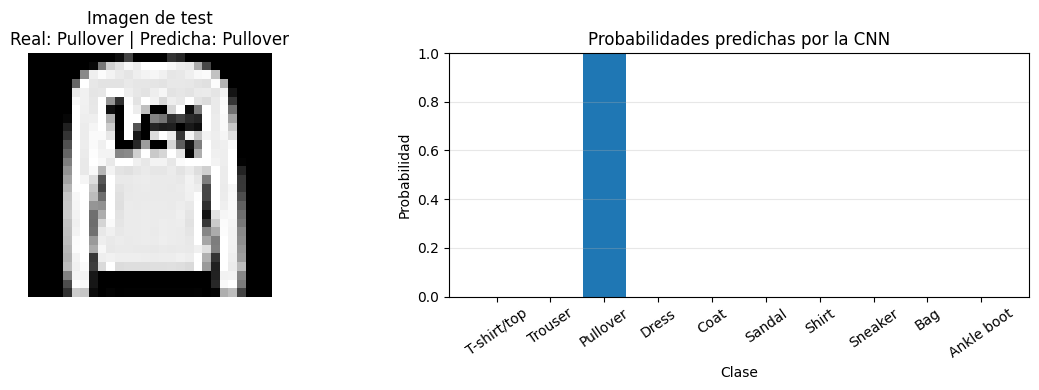

,clase,probabilidad
0,Pullover,9.999976e-01
1,Coat,2.036298e-06
2,T-shirt/top,3.367364e-07
3,Shirt,1.240233e-08
4,Sandal,4.565391e-12
5,Trouser,5.795084e-13
6,Sneaker,3.589133e-13
7,Dress,3.982199e-14
8,Ankle boot,3.779543e-14
9,Bag,2.738828e-14


In [31]:
sample_idx = 1

# Imagen original sin escalar.
img_raw = X_test_raw[sample_idx]
y_true = y_test[sample_idx]

# Preparación de la imagen para la CNN.
img = img_raw.astype("float32") / 255.0
img = img.reshape(1, 28, 28, 1)

probs = model_cargado.predict(img, verbose=0)[0]
y_pred = int(np.argmax(probs))

print("Clase real:", class_names[y_true])
print("Clase predicha:", class_names[y_pred])
print(f"Probabilidad asignada a la clase predicha: {probs[y_pred]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_raw, cmap="gray")
axes[0].set_title(f"Imagen de test\nReal: {class_names[y_true]} | Predicha: {class_names[y_pred]}")
axes[0].axis("off")

axes[1].bar(class_names, probs)
axes[1].set_title("Probabilidades predichas por la CNN")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Probabilidad")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

prob_df = pd.DataFrame({
    "clase": class_names,
    "probabilidad": probs
}).sort_values("probabilidad", ascending=False).reset_index(drop=True)

display(prob_df)

## 17. Preguntas finales para el análisis

1. ¿Por qué en redes neuronales suele preferirse un esquema train/validation/test en lugar de k-fold cross-validation?
2. ¿Qué diferencias observas entre la MLP de referencia y la CNN simple?
3. ¿Qué hiperparámetros parecen tener mayor efecto en el desempeño de validation?
4. ¿La configuración con mayor macro-F1 también tiene el mayor `accuracy`?
5. ¿Qué clases se confunden más en la matriz de confusión?
6. ¿Qué señales de sobreajuste se pueden observar en las curvas de entrenamiento?
7. ¿Por qué no se debe usar el conjunto de test durante la búsqueda en grilla?